<a href="https://colab.research.google.com/github/hectrony/alpha-test/blob/main/neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
!pip install tensorflow

In [77]:
import numpy as np
import pandas as pd
import tensorflow as tf
import zipfile
import requests
import io
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split

In [78]:
url = 'https://archive.ics.uci.edu/static/public/508/qsar+oral+toxicity.zip'

# downloading .csv file
new_file = requests.get(url)

# verifying downloading
if new_file.status_code == 200:
# opening file .zip from new_file
  with zipfile.ZipFile(io.BytesIO(new_file.content)) as archivo_zip:
# listing files
    print("Files in .zip:", archivo_zip.namelist())

# extracting file
    nombre_csv = archivo_zip.namelist()[0]  # first file
    with archivo_zip.open(nombre_csv) as archivo_csv:
# load .csv in pandas dataframe
      data = pd.read_csv(archivo_csv, sep= ';')
      print(data.head())  # first rows of dataframe

else:
  print("Download ERROR", new_file.status_code)

# convert tags 'positive' and 'negative' to 1 and  0
data.iloc[:, -1] = data.iloc[:, -1].replace({'positive': 1, 'negative': 0})


Files in .zip: ['qsar_oral_toxicity.csv']
   0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.962  0.963  0.964  \
0  0    0    1    0    0    0    0    0    0    0  ...      0      0      0   
1  0    0    0    0    0    0    0    0    0    0  ...      0      0      1   
2  0    0    0    0    0    0    0    1    0    0  ...      0      0      0   
3  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  1    0    0    0    0    0    1    0    0    0  ...      0      0      0   

   0.965  0.966  0.967  0.968  0.969  0.970  negative  
0      0      0      0      0      0      0  negative  
1      0      0      0      0      0      0  negative  
2      0      0      0      0      0      0  negative  
3      0      0      0      0      0      0  negative  
4      0      0      1      0      0      0  negative  

[5 rows x 1025 columns]


<ipython-input-78-a9a78ba645aa>:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.iloc[:, -1] = data.iloc[:, -1].replace({'positive': 1, 'negative': 0})


In [79]:
# load data function
def load_data(data):
  X = data.iloc[:, :-1].values  # atriibutes
  y = data.iloc[:, -1].values   # tags
  return X, y

In [80]:
# built model function
def build_model(input_shape):
  model = Sequential()
  model.add(Dense(32, activation='relu'))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(16, activation='relu'))
  model.add(Dense(16, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))  # out layer for binary clasification
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [81]:
# viiew training  data
def plot_training_history(history):
  plt.plot(history.history['accuracy'], label='accuracy')
  plt.plot(history.history['val_accuracy'], label='val_accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(loc='lower right')
  plt.show()

In [82]:
# loading data
X, y = load_data(data)

In [83]:
# split data -> teest and training
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.astype('int32')
X_val = X_val.astype('int32')
y_train = y_train.astype('int32')
y_val = y_val.astype('int32')

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8769 - loss: 0.3756 - val_accuracy: 0.9250 - val_loss: 0.2074
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9334 - loss: 0.1866 - val_accuracy: 0.9333 - val_loss: 0.1940
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9472 - loss: 0.1463 - val_accuracy: 0.9355 - val_loss: 0.2140
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9597 - loss: 0.1048 - val_accuracy: 0.9339 - val_loss: 0.2172
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9697 - loss: 0.0819 - val_accuracy: 0.9416 - val_loss: 0.2511
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9738 - loss: 0.0696 - val_accuracy: 0.9288 - val_loss: 0.2869
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9816 - loss: 0.0519 - val_accuracy: 0.9216 - val_loss: 0.2876
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9834 - loss: 0.0418 - val_accuracy: 0

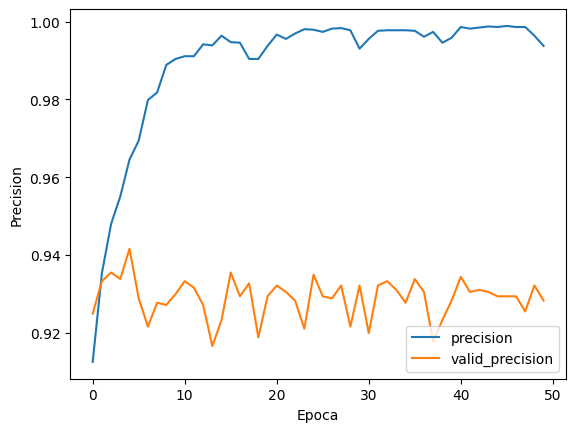

In [84]:
# building model
model = build_model(X_train.shape[1])

# training model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

# view training data
plot_training_history(history)

In [85]:
# review the modeel
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Loss in the validation set:      {loss}')
print(f'Acccuracy in the validation set: {accuracy}')

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9334 - loss: 0.5022
Loss in the validation set:      0.5346709489822388
Acccuracy in the validation set: 0.9282935261726379
